# ** Exploratory Data Analysis & Statistical Insights**

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Find uploaded Excel file

import os

excel_files = [
    file for file in os.listdir()
    if file.endswith(".xlsx")
]

print("Excel files found:")
print(excel_files)

Excel files found:
['Exploratory Data Analysis Dataset.xlsx']


In [ ]:
# Load Dataset

file_path = excel_files[0]

df = pd.read_excel(
    file_path,
    sheet_name="Online Retail"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 541909
Columns: 8


In [ ]:
# Dataset Overview

print("First 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset shape:
(541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


In [ ]:
# Missing Value Analysis

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(missing_summary)

,Missing Count,Missing Percentage
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [ ]:
# Duplicate Analysis

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [ ]:
# |Data Preparation

eda_df = df.copy()

eda_df["InvoiceDate"] = pd.to_datetime(
    eda_df["InvoiceDate"],
    errors="coerce"
)

eda_df = eda_df.dropna(
    subset=["InvoiceDate"]
)

eda_df = eda_df[
    ~eda_df["InvoiceNo"].astype(str).str.startswith("C")
]

eda_df = eda_df[
    eda_df["Quantity"] > 0
]

eda_df = eda_df[
    eda_df["UnitPrice"] > 0
]

print("Original rows:", len(df))
print("Rows after preparation:", len(eda_df))

Original rows: 541909
Rows after preparation: 530104


In [ ]:
#  Create Revenue Feature

eda_df["Revenue"] = (
    eda_df["Quantity"] *
    eda_df["UnitPrice"]
)

display(
    eda_df[
        ["Quantity", "UnitPrice", "Revenue"]
    ].head()
)

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
# Create Time Features

eda_df["Year"] = eda_df["InvoiceDate"].dt.year
eda_df["Month"] = eda_df["InvoiceDate"].dt.month
eda_df["Month Name"] = eda_df["InvoiceDate"].dt.month_name()
eda_df["Day of Week"] = eda_df["InvoiceDate"].dt.day_name()
eda_df["Hour"] = eda_df["InvoiceDate"].dt.hour

display(
    eda_df[
        [
            "InvoiceDate",
            "Year",
            "Month",
            "Month Name",
            "Day of Week",
            "Hour"
        ]
    ].head()
)

,InvoiceDate,Year,Month,Month Name,Day of Week,Hour
0,2010-12-01 08:26:00,2010,12,December,Wednesday,8
1,2010-12-01 08:26:00,2010,12,December,Wednesday,8
2,2010-12-01 08:26:00,2010,12,December,Wednesday,8
3,2010-12-01 08:26:00,2010,12,December,Wednesday,8
4,2010-12-01 08:26:00,2010,12,December,Wednesday,8


In [ ]:
# Descriptive Statistics

numeric_columns = [
    "Quantity",
    "UnitPrice",
    "Revenue"
]

descriptive_stats = eda_df[
    numeric_columns
].describe().T

descriptive_stats["Median"] = eda_df[
    numeric_columns
].median()

display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,Median
Quantity,530104.0,10.542037,155.524124,1.000,1.00,3.00,10.00,80995.00,3.00
UnitPrice,530104.0,3.907625,35.915681,0.001,1.25,2.08,4.13,13541.33,2.08
Revenue,530104.0,20.121871,270.356743,0.001,3.75,9.90,17.70,168469.60,9.90


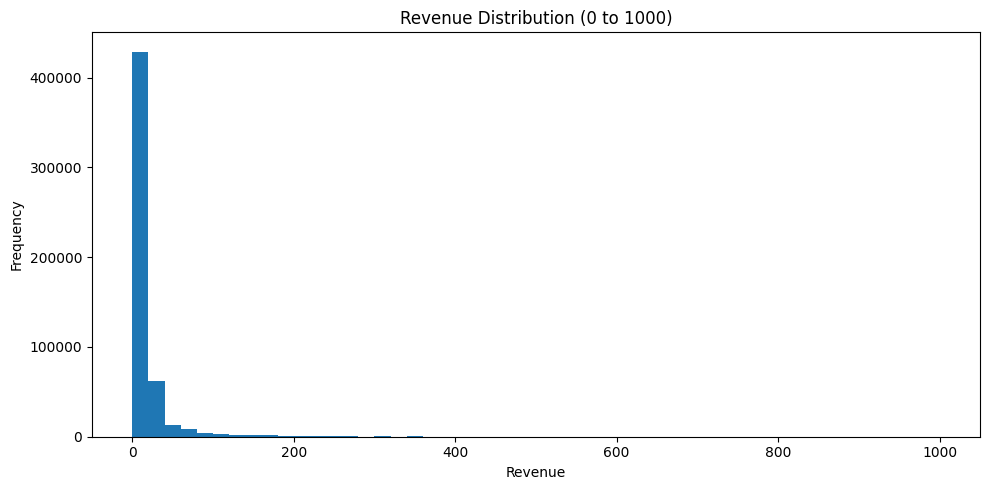

In [ ]:
# Revenue Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    eda_df["Revenue"],
    bins=50,
    range=(0, 1000)
)

plt.title("Revenue Distribution (0 to 1000)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

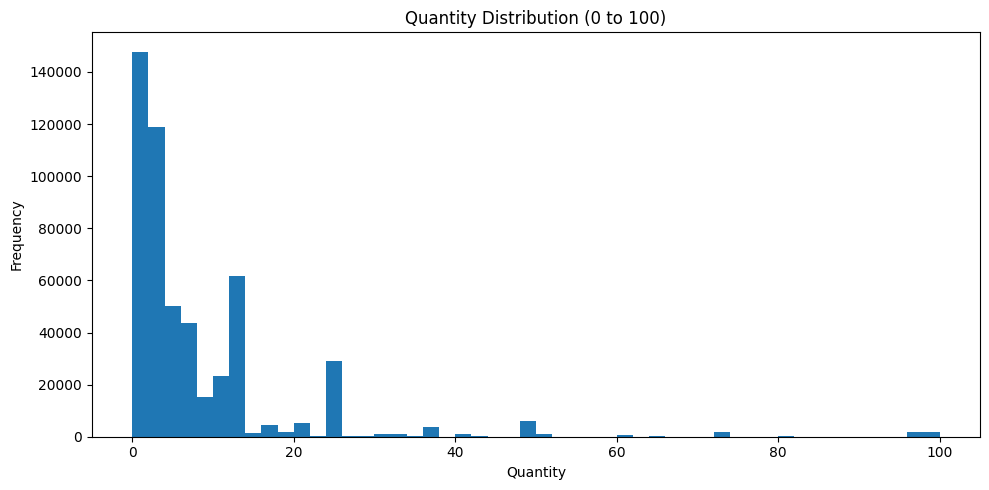

In [ ]:
# Quantity Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    eda_df["Quantity"],
    bins=50,
    range=(0, 100)
)

plt.title("Quantity Distribution (0 to 100)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

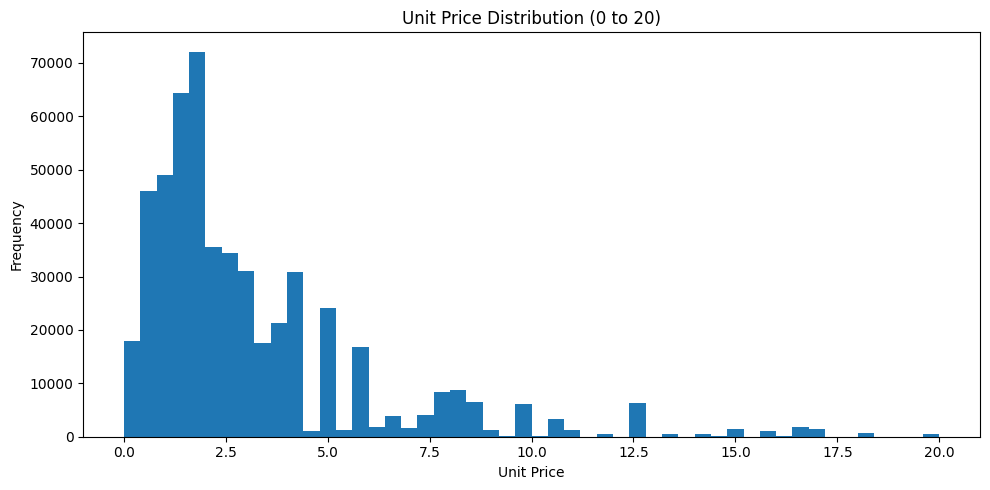

In [ ]:
# Unit Price Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    eda_df["UnitPrice"],
    bins=50,
    range=(0, 20)
)

plt.title("Unit Price Distribution (0 to 20)")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

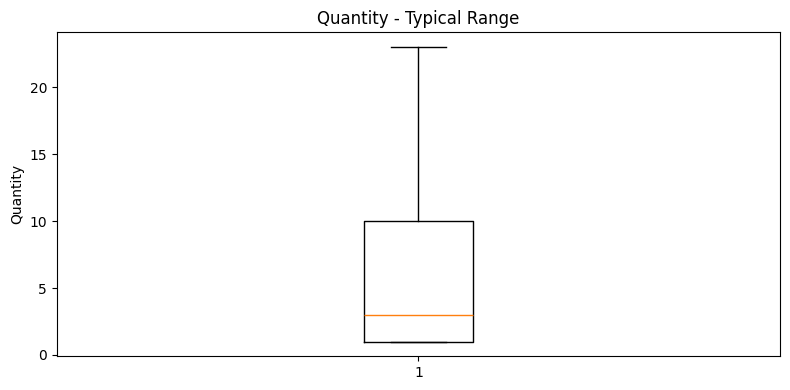

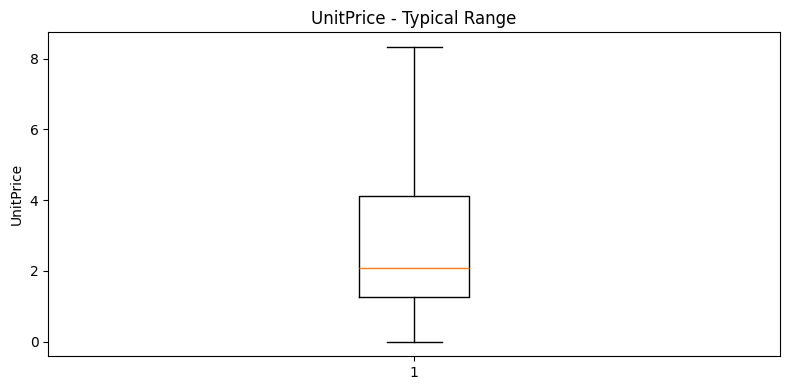

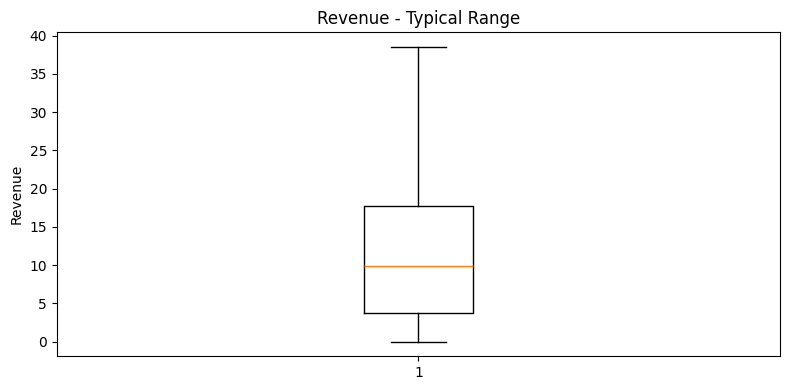

In [ ]:
#  Focused Box Plots

for column in ["Quantity", "UnitPrice", "Revenue"]:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        eda_df[column].dropna(),
        showfliers=False
    )

    plt.title(f"{column} - Typical Range")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

In [ ]:
# Correlation Matrix

correlation_matrix = eda_df[
    [
        "Quantity",
        "UnitPrice",
        "Revenue"
    ]
].corr()

display(correlation_matrix)

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003773,0.907338
UnitPrice,-0.003773,1.000000,0.137404
Revenue,0.907338,0.137404,1.000000


In [ ]:
# Country-wise Revenue Analysis

country_analysis = (
    eda_df
    .groupby("Country")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Invoices=("InvoiceNo", "nunique"),
        Average_Revenue=("Revenue", "mean")
    )
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
)

display(country_analysis.head(10))

,Total_Revenue,Total_Quantity,Number_of_Invoices,Average_Revenue
Country,,,,
United Kingdom,9025222.084,4662390,18019,18.603987
Netherlands,285446.340,200361,94,121.003111
EIRE,283453.960,147173,288,35.925724
Germany,228867.140,119261,457,25.317162
France,209715.110,112103,392,24.945297
Australia,138521.310,83901,57,117.192310
Spain,61577.110,27940,90,24.789497
Switzerland,57089.900,30629,54,29.038606
Belgium,41196.340,23237,98,20.283772


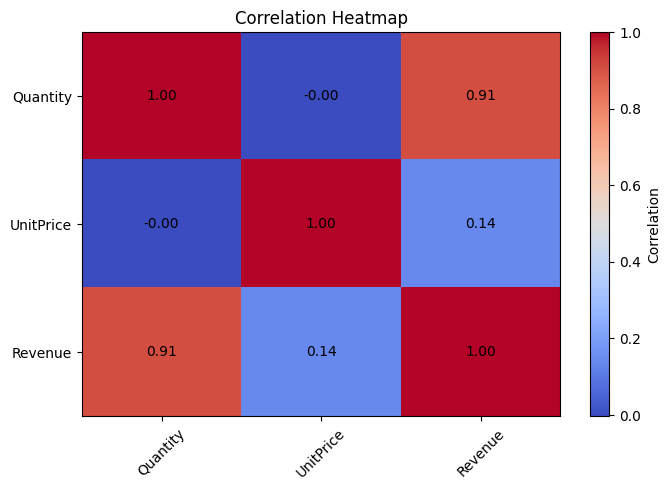

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Heatmap")

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):

        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

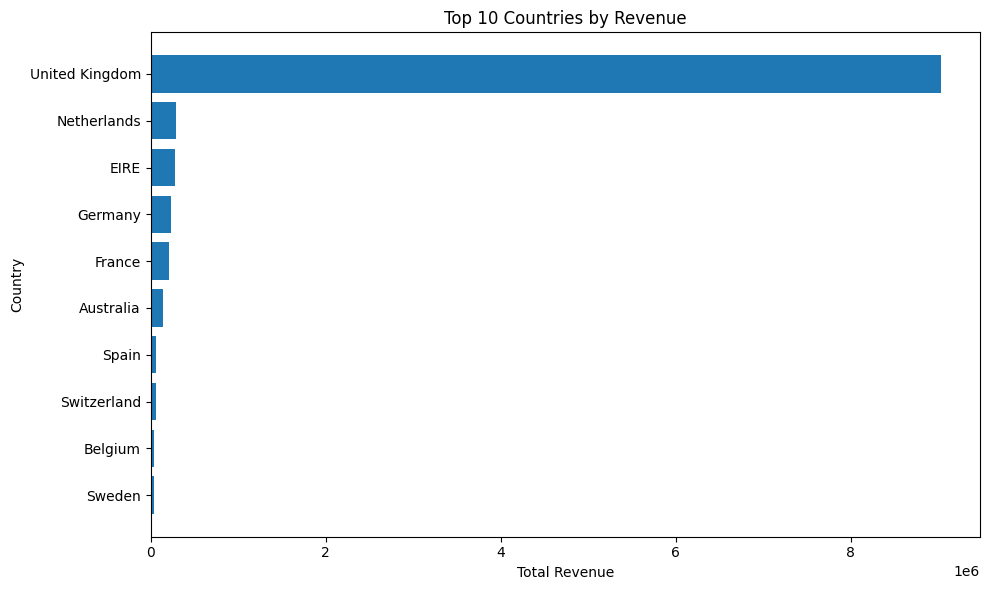

In [ ]:
#  Top 10 Countries by Revenue

top_countries = country_analysis.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries.index[::-1],
    top_countries["Total_Revenue"][::-1]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [ ]:
#  Monthly Revenue Analysis

monthly_revenue = (
    eda_df
    .groupby(["Year", "Month"])["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["Period"] = (
    monthly_revenue["Year"].astype(str)
    + "-"
    + monthly_revenue["Month"].astype(str).str.zfill(2)
)

display(monthly_revenue)

,Year,Month,Revenue,Period
0,2010,12,823746.140,2010-12
1,2011,1,691364.560,2011-01
2,2011,2,523631.890,2011-02
3,2011,3,717639.360,2011-03
4,2011,4,537808.621,2011-04
5,2011,5,770536.020,2011-05
6,2011,6,761739.900,2011-06
7,2011,7,719221.191,2011-07
8,2011,8,759138.380,2011-08
9,2011,9,1058590.172,2011-09


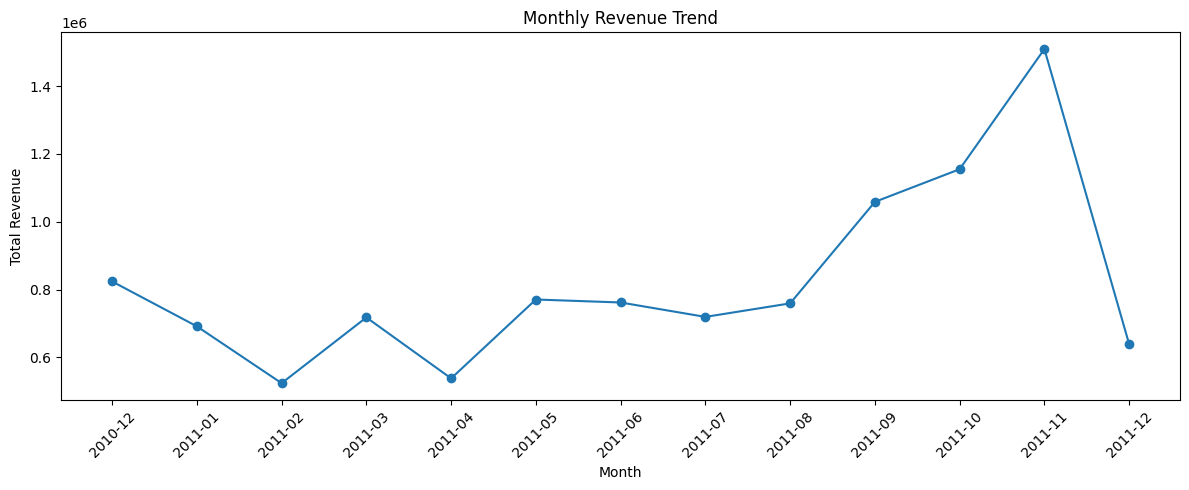

In [ ]:
#Monthly Revenue Trend

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["Period"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#Top 10 Products by Revenue

product_analysis = (
    eda_df
    .groupby("Description")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
)

display(product_analysis.head(10))

,Total_Revenue,Total_Quantity
Description,,
DOTCOM POSTAGE,206248.77,706
REGENCY CAKESTAND 3 TIER,174484.74,13879
"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
WHITE HANGING HEART T-LIGHT HOLDER,106292.77,37891
PARTY BUNTING,99504.33,18295
JUMBO BAG RED RETROSPOT,94340.05,48474
MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033
Manual,78112.82,7225
POSTAGE,78101.88,3150


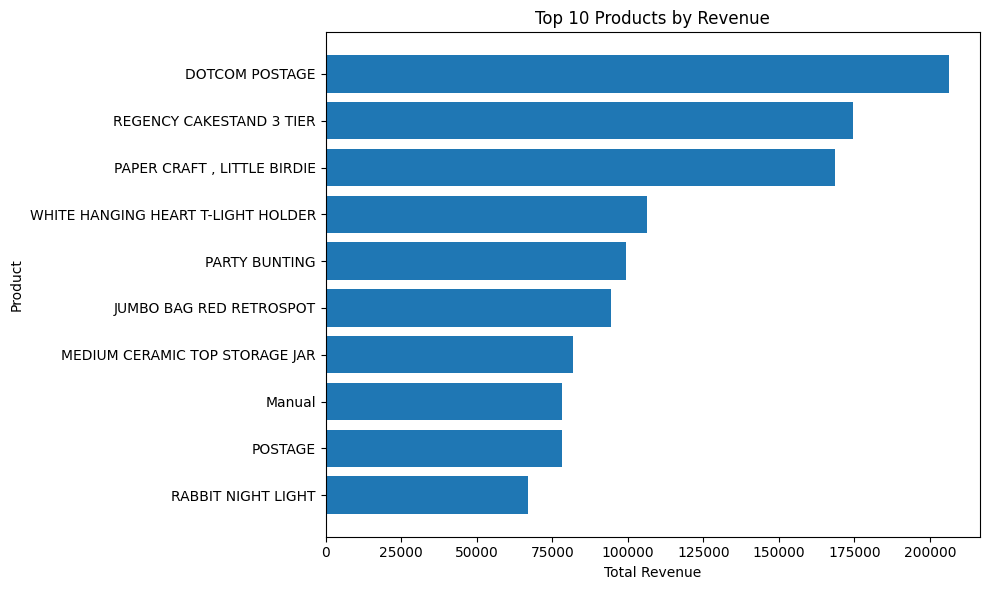

In [ ]:
# Top 10 Products Visualization

top_products = product_analysis.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index[::-1],
    top_products["Total_Revenue"][::-1]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [ ]:
#Hypothesis 1 - Purchase Frequency vs Revenue

customer_analysis = (
    eda_df
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        Purchase_Frequency=("InvoiceNo", "nunique"),
        Total_Revenue=("Revenue", "sum")
    )
    .reset_index()
)

h1_correlation, h1_p_value = stats.spearmanr(
    customer_analysis["Purchase_Frequency"],
    customer_analysis["Total_Revenue"]
)

print("Hypothesis 1")
print("Spearman Correlation:", round(h1_correlation, 4))
print("P-value:", h1_p_value)

if h1_p_value < 0.05:
    print("Conclusion: Reject H0.")
    print("There is a statistically significant relationship between purchase frequency and customer revenue.")
else:
    print("Conclusion: Fail to reject H0.")
    print("There is not enough evidence of a significant relationship.")

Hypothesis 1
Spearman Correlation: 0.8075
P-value: 0.0
Conclusion: Reject H0.
There is a statistically significant relationship between purchase frequency and customer revenue.


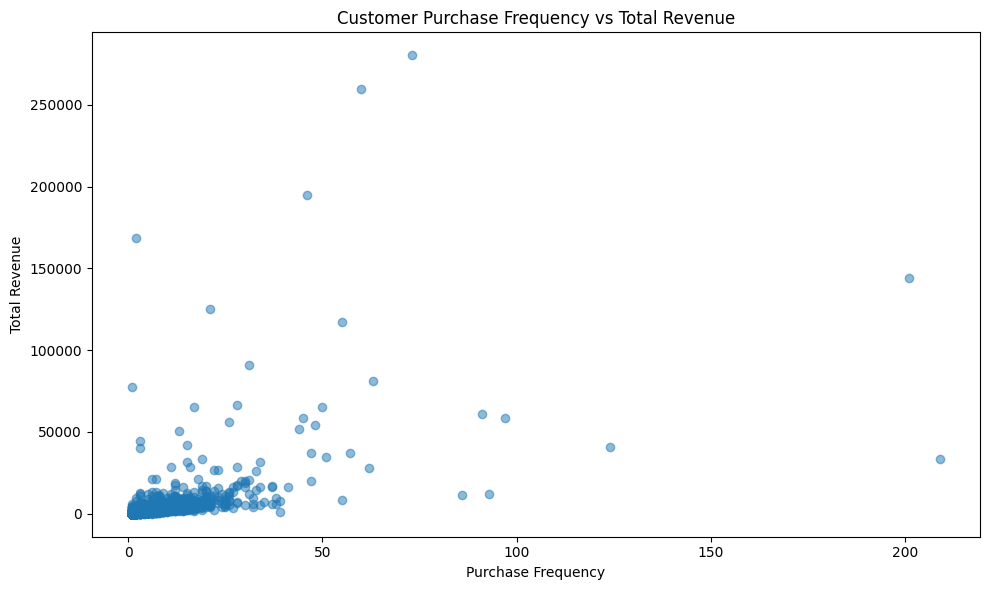

In [ ]:
# Purchase Frequency vs Revenue

plt.figure(figsize=(10, 6))

plt.scatter(
    customer_analysis["Purchase_Frequency"],
    customer_analysis["Total_Revenue"],
    alpha=0.5
)

plt.title("Customer Purchase Frequency vs Total Revenue")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

In [ ]:
#Hypothesis 2 - UK vs Non-UK Revenue

uk_revenue = eda_df[
    eda_df["Country"] == "United Kingdom"
]["Revenue"]

non_uk_revenue = eda_df[
    eda_df["Country"] != "United Kingdom"
]["Revenue"]

h2_statistic, h2_p_value = stats.mannwhitneyu(
    uk_revenue,
    non_uk_revenue,
    alternative="two-sided"
)

print("Hypothesis 2")
print("Mann-Whitney U Statistic:", h2_statistic)
print("P-value:", h2_p_value)

print("UK Median Revenue:", round(uk_revenue.median(), 2))
print("Non-UK Median Revenue:", round(non_uk_revenue.median(), 2))

if h2_p_value < 0.05:
    print("Conclusion: Reject H0.")
    print("Transaction revenue differs significantly between UK and non-UK transactions.")
else:
    print("Conclusion: Fail to reject H0.")
    print("There is not enough evidence of a significant difference.")

Hypothesis 2
Mann-Whitney U Statistic: 5712161120.0
P-value: 0.0
UK Median Revenue: 8.42
Non-UK Median Revenue: 17.4
Conclusion: Reject H0.
Transaction revenue differs significantly between UK and non-UK transactions.


/tmp/ipykernel_1001/9029767.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


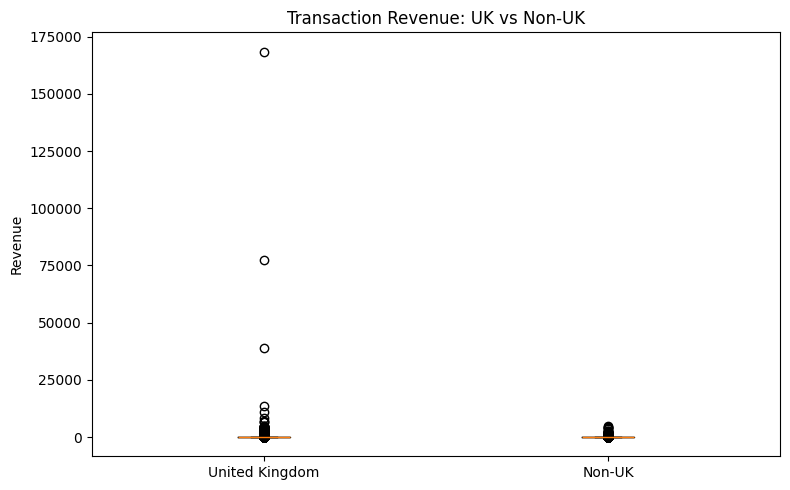

In [ ]:
# UK vs Non-UK Revenue

plt.figure(figsize=(8, 5))

plt.boxplot(
    [uk_revenue, non_uk_revenue],
    labels=["United Kingdom", "Non-UK"]
)

plt.title("Transaction Revenue: UK vs Non-UK")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [ ]:
# Hypothesis 3 - Revenue Across Months

monthly_groups = []

for month in sorted(eda_df["Month"].dropna().unique()):

    monthly_groups.append(
        eda_df[
            eda_df["Month"] == month
        ]["Revenue"]
    )

h3_statistic, h3_p_value = stats.kruskal(
    *monthly_groups
)

print("Hypothesis 3")
print("Kruskal-Wallis Statistic:", h3_statistic)
print("P-value:", h3_p_value)

if h3_p_value < 0.05:
    print("Conclusion: Reject H0.")
    print("There is a statistically significant difference in revenue across months.")
else:
    print("Conclusion: Fail to reject H0.")
    print("There is not enough evidence of a significant difference across months.")

Hypothesis 3
Kruskal-Wallis Statistic: 3589.6912738712176
P-value: 0.0
Conclusion: Reject H0.
There is a statistically significant difference in revenue across months.


In [ ]:
# Hypothesis Results Summary

hypothesis_results = pd.DataFrame({
    "Hypothesis": [
        "Purchase frequency vs customer revenue",
        "UK vs non-UK transaction revenue",
        "Revenue differences across months"
    ],
    "Statistical Test": [
        "Spearman Correlation",
        "Mann-Whitney U Test",
        "Kruskal-Wallis Test"
    ],
    "Test Statistic": [
        h1_correlation,
        h2_statistic,
        h3_statistic
    ],
    "P-Value": [
        h1_p_value,
        h2_p_value,
        h3_p_value
    ],
    "Result": [
        "Significant" if h1_p_value < 0.05 else "Not Significant",
        "Significant" if h2_p_value < 0.05 else "Not Significant",
        "Significant" if h3_p_value < 0.05 else "Not Significant"
    ]
})

display(hypothesis_results)

,Hypothesis,Statistical Test,Test Statistic,P-Value,Result
0,Purchase frequency vs customer revenue,Spearman Correlation,8.074839e-01,0.0,Significant
1,UK vs non-UK transaction revenue,Mann-Whitney U Test,5.712161e+09,0.0,Significant
2,Revenue differences across months,Kruskal-Wallis Test,3.589691e+03,0.0,Significant


In [ ]:
# Calculate Key Business Metrics

total_revenue = eda_df["Revenue"].sum()
average_transaction_revenue = eda_df["Revenue"].mean()
median_transaction_revenue = eda_df["Revenue"].median()

total_quantity = eda_df["Quantity"].sum()
unique_invoices = eda_df["InvoiceNo"].nunique()
unique_customers = eda_df["CustomerID"].nunique()

print("Key Business Metrics")
print("--------------------")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Average Transaction Revenue: {average_transaction_revenue:,.2f}")
print(f"Median Transaction Revenue: {median_transaction_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,.0f}")
print(f"Unique Invoices: {unique_invoices:,}")
print(f"Unique Customers: {unique_customers:,}")

Key Business Metrics
--------------------
Total Revenue: 10,666,684.54
Average Transaction Revenue: 20.12
Median Transaction Revenue: 9.90
Total Quantity Sold: 5,588,376
Unique Invoices: 19,960
Unique Customers: 4,338


In [ ]:
# Step 30: Identify Top Findings

top_country = country_analysis.index[0]
top_country_revenue = country_analysis.iloc[0]["Total_Revenue"]

highest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

top_product = product_analysis.index[0]
top_product_revenue = product_analysis.iloc[0]["Total_Revenue"]

print("Top Findings")
print("------------")

print(
    f"Top country by revenue: {top_country}"
)

print(
    f"Top country revenue: {top_country_revenue:,.2f}"
)

print(
    f"Highest revenue month: {highest_month['Period']}"
)

print(
    f"Highest month revenue: {highest_month['Revenue']:,.2f}"
)

print(
    f"Top product by revenue: {top_product}"
)

print(
    f"Top product revenue: {top_product_revenue:,.2f}"
)

Top Findings
------------
Top country by revenue: United Kingdom
Top country revenue: 9,025,222.08
Highest revenue month: 2011-11
Highest month revenue: 1,509,496.33
Top product by revenue: DOTCOM POSTAGE
Top product revenue: 206,248.77


In [ ]:
#  Top 5 Critical Findings

print("Top 5 Critical Findings")
print("=======================")

print(
    f"1. The dataset generated total revenue of "
    f"{total_revenue:,.2f} from the analyzed transactions."
)

print(
    f"2. {top_country} was the highest-revenue country, "
    f"generating {top_country_revenue:,.2f}."
)

print(
    f"3. The highest-revenue period was {highest_month['Period']}, "
    f"with revenue of {highest_month['Revenue']:,.2f}."
)

print(
    f"4. '{top_product}' was the highest-revenue product, "
    f"generating {top_product_revenue:,.2f}."
)

print(
    f"5. Customer purchase frequency had a Spearman correlation "
    f"of {h1_correlation:.4f} with customer revenue "
    f"(p-value = {h1_p_value:.4g})."
)

Top 5 Critical Findings
1. The dataset generated total revenue of 10,666,684.54 from the analyzed transactions.
2. United Kingdom was the highest-revenue country, generating 9,025,222.08.
3. The highest-revenue period was 2011-11, with revenue of 1,509,496.33.
4. 'DOTCOM POSTAGE' was the highest-revenue product, generating 206,248.77.
5. Customer purchase frequency had a Spearman correlation of 0.8075 with customer revenue (p-value = 0).
